## SHAP-Werte berechnen mittels CV und globaler Plot 

In [10]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx",
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")




SHAP-Wertprüfung:
→ Min: -4.601785791104535 Max: 4.450765755077146 Mean: -0.008208019231255208
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
UNINV_CMJ_uni_Av. propulsive force                                 +0.004071        0.854297
INV_CMJ_uni_Peak braking force                                     -0.000574        0.715671
INV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]            +0.004617        0.633747
INV_CMJ_uni_Av. braking force                                      -0.004881        0.595890
INV_CMJ_uni_Peak Braking Velocity-Mittelwert [m/s]                 -0.009128        0.564008
INV_CMJ_uni_Propulsive Duration-Mittelwert [s]                     -0.025928        0.481260
INV_ISO_Drehmoment_Verhaeltnis Flexion Extension                   -0.007054        0.477746

## SHAP Kontrolle

In [11]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end   = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap   = []
p_from_model  = []

for i in idx_local:
    logit_i = exp_val + shap_stack[i].sum()        # log-odds rekonstruiert
    p_from_shap.append(expit(logit_i))             # -> Wahrscheinlichkeit
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap  = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model
print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")




=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 1.110e-16
Mittlere Abweichung : 2.776e-17
Median Abweichung   : 0.000e+00

P_SHAP=0.165161 | P_Modell=0.165161 | Δ=-2.78e-17
P_SHAP=0.018530 | P_Modell=0.018530 | Δ=+0.00e+00
P_SHAP=0.736701 | P_Modell=0.736701 | Δ=-1.11e-16
P_SHAP=0.950998 | P_Modell=0.950998 | Δ=+0.00e+00
P_SHAP=0.014240 | P_Modell=0.014240 | Δ=+0.00e+00


## Globaler SHAP Plot (signed mean SHAP)

→ Globaler Diverging Bar-Plot: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\global_diverging_bar.png


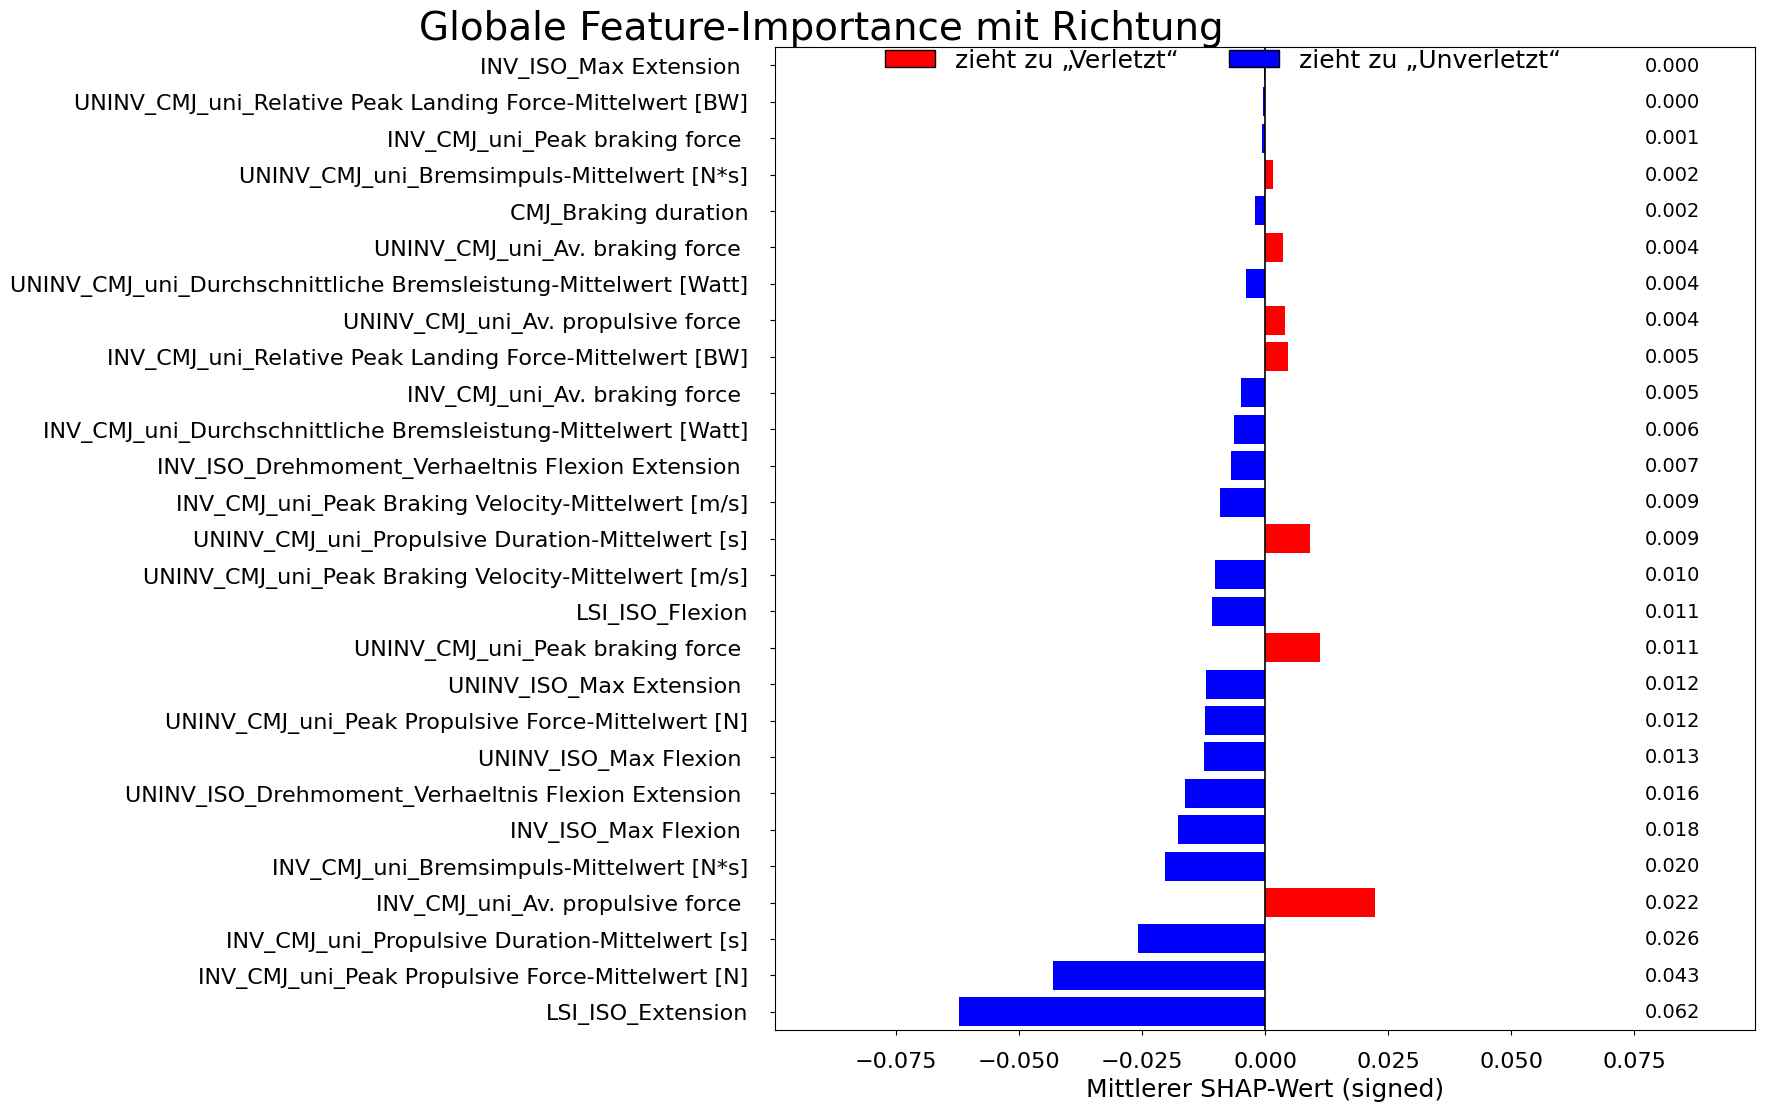

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

shap_output_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"

def plot_global_diverging_bar(
    features, 
    shap_stack, 
    output_dir, 
    title="Globale Feature-Importance mit Richtung",
    dpi=200
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    # 1) Mittelwerte (signed) und Beträge
    mean_shap = np.mean(shap_stack, axis=0)      # signed mean(SHAP)
    importance = np.abs(mean_shap)               # |signed mean|

    # === Sortierung: absteigend nach Betrag → größter Betrag ist ERSTER Eintrag
    #     Bei barh erscheint der erste Eintrag UNTEN → gewünschtes Verhalten.
    idx_sort  = np.argsort(importance)[::-1]

    feat_sorted      = [features[i] for i in idx_sort]
    mean_shap_sorted = mean_shap[idx_sort]       # Balken (signed) für Richtung
    abs_sorted       = importance[idx_sort]      # Zahlen rechts: Betrag
    colors           = ['red' if v >= 0 else 'blue' for v in mean_shap_sorted]

    # 2) Puffer & Limits
    max_abs = abs_sorted.max() if len(abs_sorted) else 1.0
    margin  = max_abs * 0.6

    # 3) Figur
    fig_h = max(10, len(feat_sorted) * 0.4)
    fig_w = 14
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    fig.suptitle(title, fontsize=28, y=0.965, ha='right')

    # 4) Legende
    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    fig.legend(handles=legend_elements, fontsize=18, loc='upper center',
               ncol=2, bbox_to_anchor=(0.5, 0.95), frameon=False)

    # 5) Balken
    ax.barh(feat_sorted, mean_shap_sorted, color=colors, height=0.8)
    ax.axvline(0, color='black', linewidth=1.2)

    # 6) Achsen & Limits
    ax.set_xlabel("Mittlerer SHAP-Wert (signed)", fontsize=18)
    ax.tick_params(axis='y', labelsize=16, pad=16)
    ax.tick_params(axis='x', labelsize=16, pad=12)
    ax.set_xlim(-max_abs - margin, max_abs + margin)

    # 7) Zahlen rechts (Betrag)
    x_text = max_abs + margin * 0.4
    for i, val in enumerate(abs_sorted):
        ax.text(x_text, i, f"{val:.3f}", va='center', ha='left', fontsize=14)

    # 8) Layout
    ax.set_ylim(-0.5, len(feat_sorted)-0.5)
    ax.margins(y=0)
    # WICHTIG: Nicht invertieren, sonst wandert der größte wieder nach oben!
    # ax.invert_yaxis()  # <-- NICHT setzen

    plt.subplots_adjust(top=0.93, bottom=0.02, left=0.18, right=0.88)

    # 9) Speichern & Anzeigen
    out = os.path.join(output_dir, "global_diverging_bar.png")
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f"→ Globaler Diverging Bar-Plot: {out}")
    plt.show()


# # Aufruf
plot_global_diverging_bar(
    features=features, 
    shap_stack=shap_stack, 
    output_dir=shap_output_dir
)


### Globaler Plot (meanSHAP und Richtung über signed mean SHAP)

→ Global-Plot gespeichert: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\global_importance_classic.png


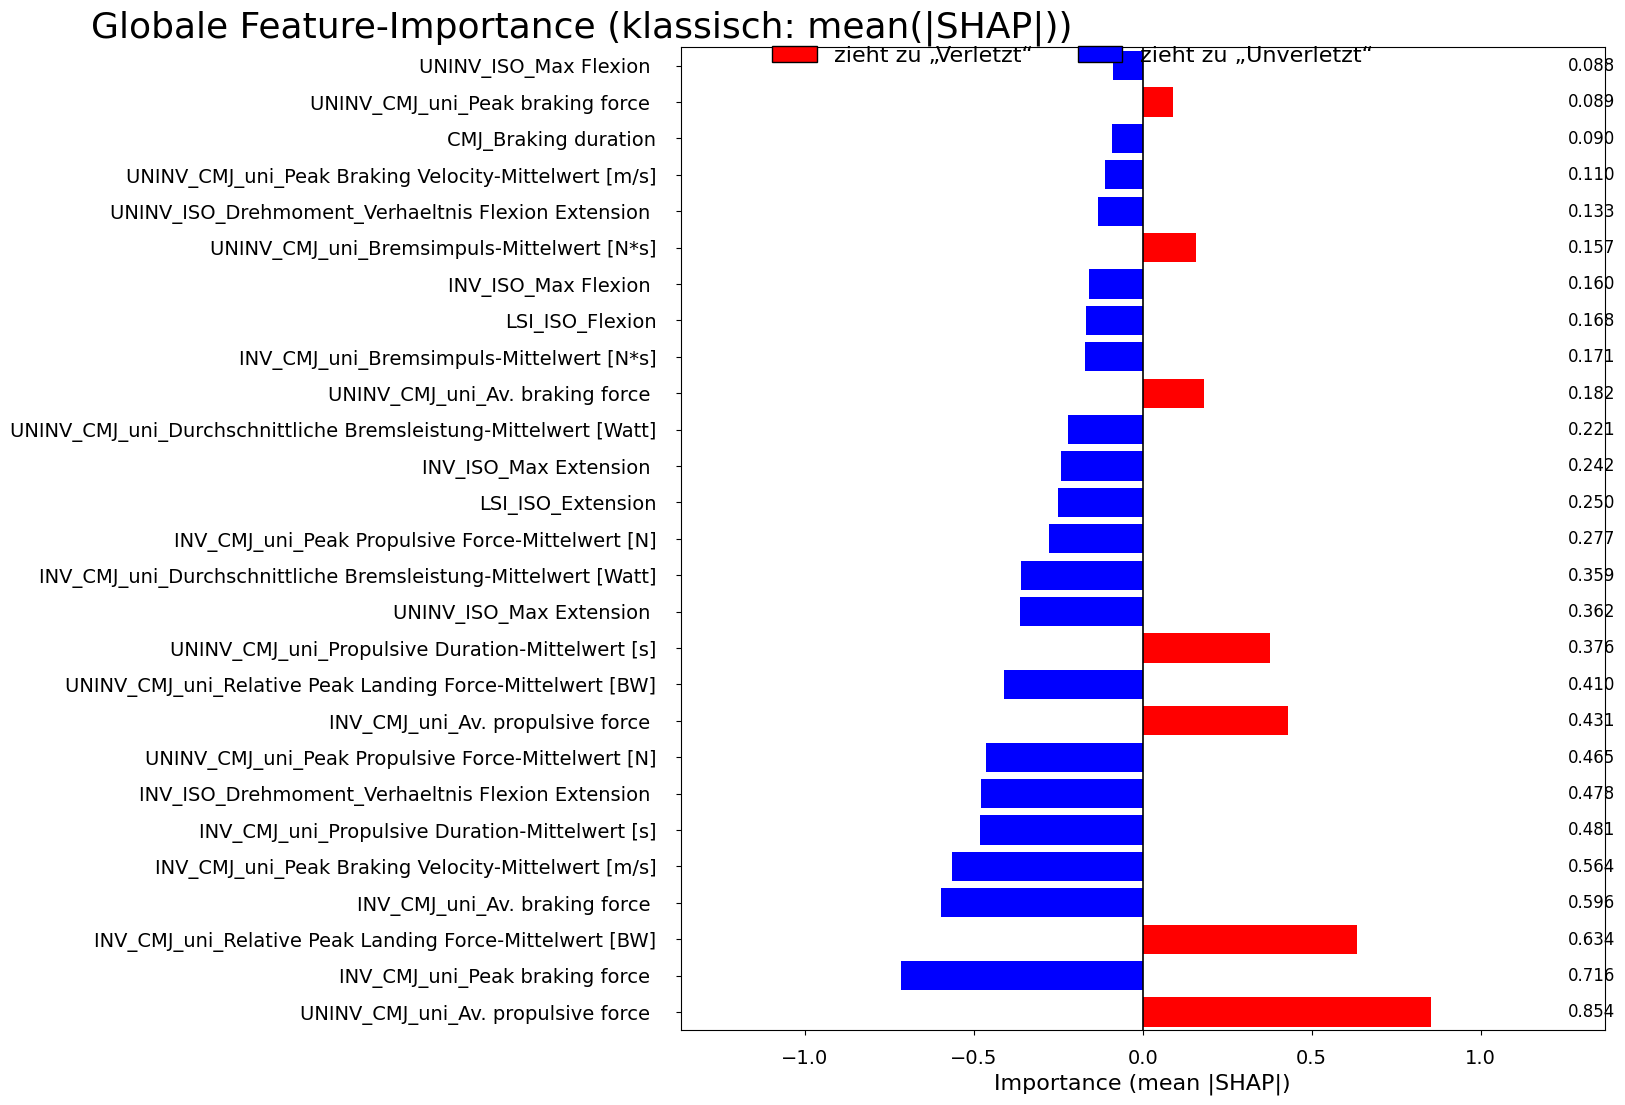

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_global_importance_classic(
    features,
    shap_stack,
    output_dir,
    title="Globale Feature-Importance (klassisch: mean(|SHAP|))",
    dpi=200,
    diverging=True,          # True: links/rechts je nach Richtung; False: alle nach rechts
    largest_at_bottom=True   # True: Top-Features unten
):
    # Kennzahlen
    signed_mean = np.mean(shap_stack, axis=0)          # mean(SHAP) (Richtung)
    mean_abs    = np.mean(np.abs(shap_stack), axis=0)  # mean(|SHAP|) (klassische Importance)

    # Sortierung nach klassischer Importance
    order = np.argsort(mean_abs)[::-1] if largest_at_bottom else np.argsort(mean_abs)

    feat_sorted   = [features[i] for i in order]
    dir_sign      = np.sign(signed_mean[order])  # -1, 0, +1
    importance    = mean_abs[order]              # Längen

    if diverging:
        # Divergend: Länge = mean(|SHAP|), Richtung = sign(mean(SHAP))
        bar_vals = importance * np.where(dir_sign==0, 1.0, dir_sign)
        colors   = ['red' if s >= 0 else 'blue' for s in dir_sign]
        x_min, x_max = -bar_vals.__abs__().max()*1.6, bar_vals.__abs__().max()*1.6
    else:
        # Klassischer SHAP-Bar: alle Balken nach rechts, Farbe zeigt Richtung
        bar_vals = importance
        colors   = ['red' if s >= 0 else 'blue' for s in dir_sign]
        x_min, x_max = 0.0, bar_vals.max()*1.6

    # Plot
    fig_h = max(10, len(feat_sorted)*0.4)
    fig, ax = plt.subplots(figsize=(14, fig_h))
    fig.suptitle(title, fontsize=26, y=0.965, ha='right')

    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    fig.legend(handles=legend_elements, fontsize=16, loc='upper center',
               ncol=2, bbox_to_anchor=(0.5, 0.95), frameon=False)

    ax.barh(feat_sorted, bar_vals, color=colors, height=0.8)
    ax.axvline(0, color='black', linewidth=1.2)

    ax.set_xlabel("Importance (mean |SHAP|)", fontsize=16)
    ax.tick_params(axis='y', labelsize=14, pad=14)
    ax.tick_params(axis='x', labelsize=14, pad=10)
    ax.set_xlim(x_min, x_max)

    # Werte rechts (immer absolute Importance)
    x_text = x_max * 0.92
    for i, val in enumerate(importance):
        ax.text(x_text, i, f"{val:.3f}", va='center', ha='left', fontsize=12)

    ax.set_ylim(-0.5, len(feat_sorted)-0.5)
    ax.margins(y=0)

    plt.subplots_adjust(top=0.93, bottom=0.02, left=0.22, right=0.88)

    out = os.path.join(output_dir, "global_importance_classic.png")
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f"→ Global-Plot gespeichert: {out}")
    plt.show()

plot_global_importance_classic(
    features=features,
    shap_stack=shap_stack,
    output_dir=shap_output_dir,
    diverging=True,          # oder False, wenn alle Balken nach rechts sollen
    largest_at_bottom=True
)


### Globaler Plot mit Umschalter (klassisch/signed mean) und Stabilitätsmetriken

→ gespeichert: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\bar_directional_signed_absSignedOrder.png


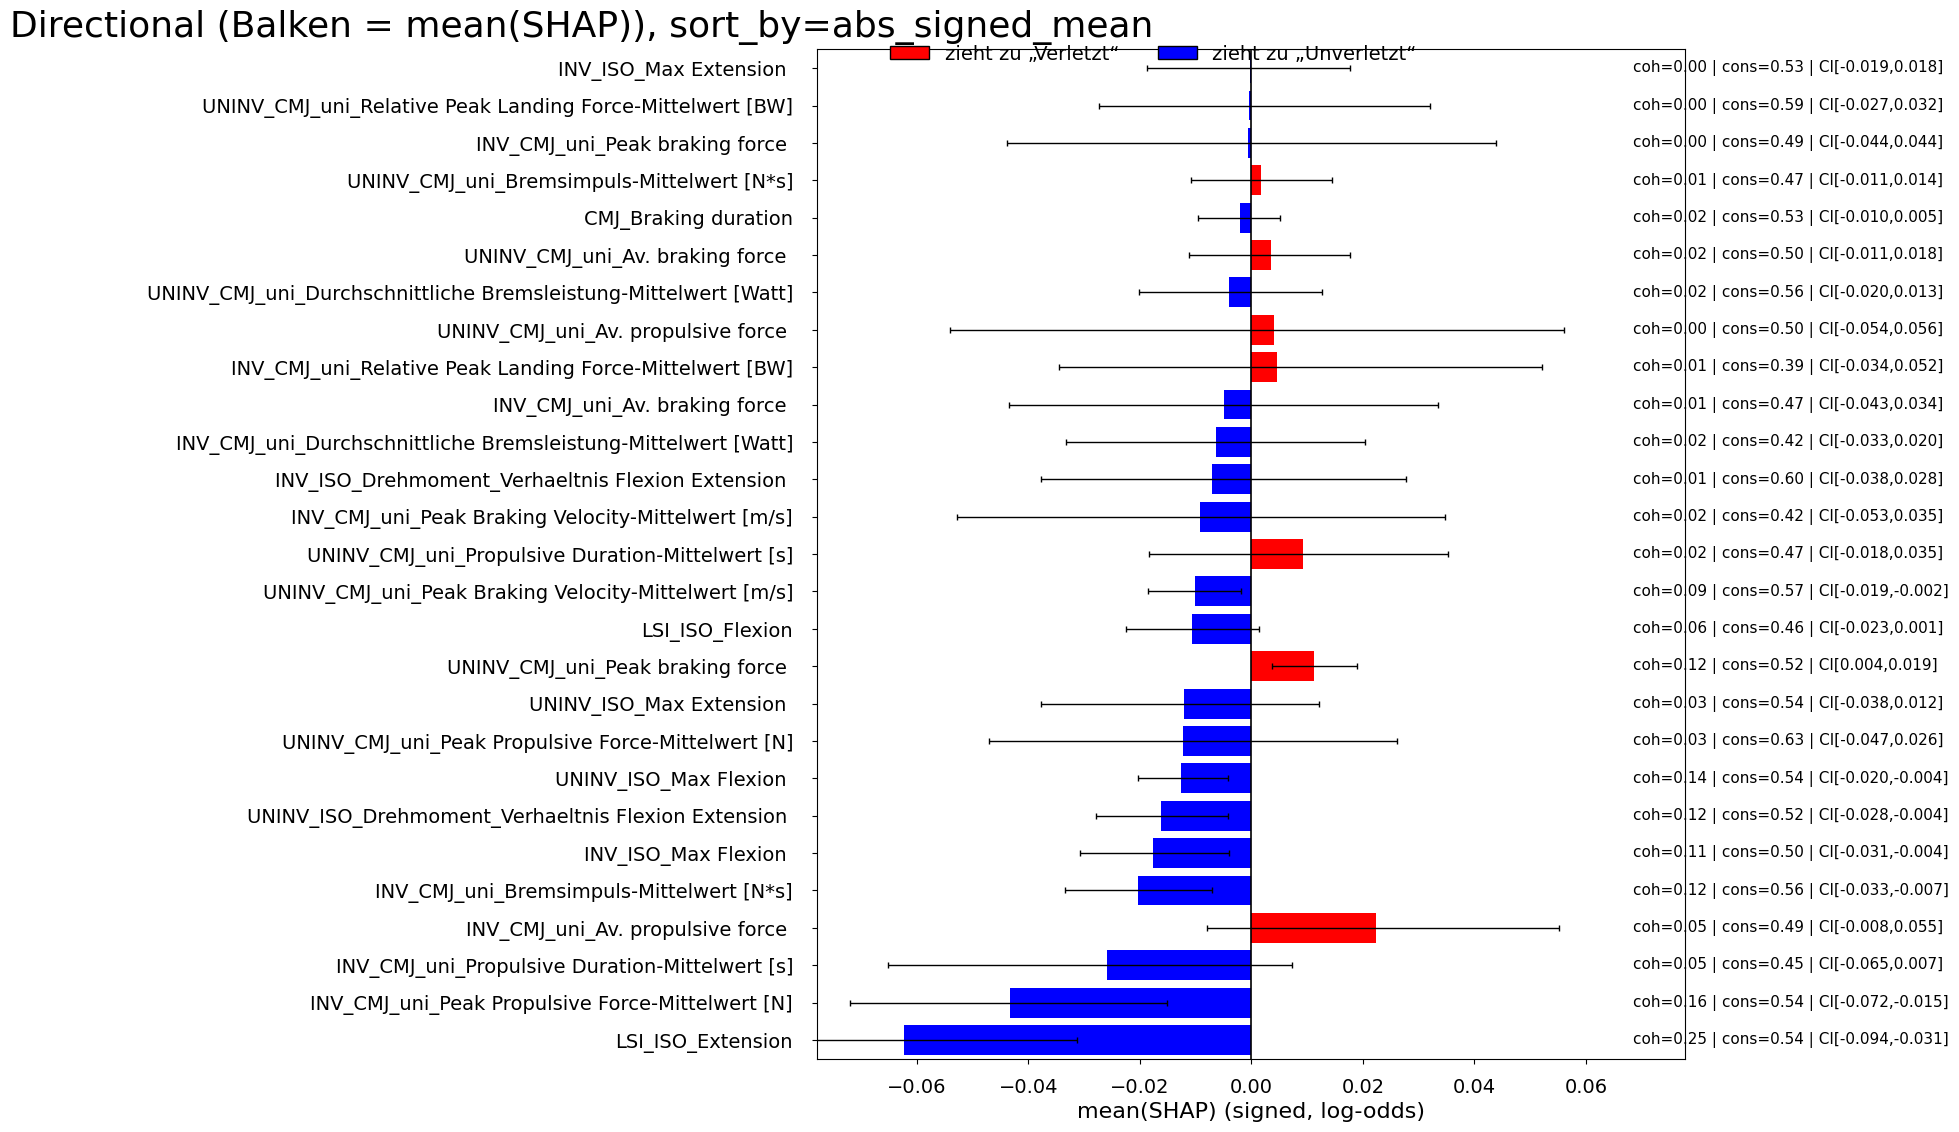

Kohärenz (coh): |mean(SHAP)| / mean(|SHAP|); 1.0 = durchgehend gleiche Richtung; 0 ≈ Auslöschung (mal +, mal −).
Konsistenz (cons): Anteil der Samples mit gleichem Vorzeichen wie globales mean(SHAP) Vorzeichen (±0 ignoriert); >0.70 ≈ meist einheitlich.
Konfidenzinterval (CI[lo,hi]): 95%-Bootstrap-CI von mean(SHAP); schneidet 0 ⇒ Richtung statistisch unsicher; schneidet 0 nicht ⇒ stabiler gerichteter Effekt.


In [ ]:
# ===== 1) Directional-Summary berechnen (signed mean + Stabilität) =====
import numpy as np
import pandas as pd

def summarize_directional_shap(shap_stack, features, n_boot=500, eps=1e-8, random_state=42):
    """
    Liefert eine Tabelle mit:
      - signed_mean         = mean(SHAP) je Feature (Richtung)
      - abs_signed_mean     = |mean(SHAP)|
      - mean_abs            = mean(|SHAP|) (klassische Importance)
      - coherence           = |mean(SHAP)| / mean(|SHAP|)
      - sample_consistency  = Anteil SHAPs mit gleichem Vorzeichen wie mean(SHAP)
      - ci_lo, ci_hi        = 95%-Bootstrap-CIs für mean(SHAP)
    """
    rng = np.random.default_rng(random_state)
    N, F = shap_stack.shape

    signed_mean = shap_stack.mean(axis=0)
    mean_abs    = np.mean(np.abs(shap_stack), axis=0)
    abs_signed  = np.abs(signed_mean)
    coherence   = np.divide(abs_signed, mean_abs, out=np.zeros_like(abs_signed), where=mean_abs > 0)

    target_sign = np.sign(signed_mean)
    shap_sign   = np.sign(shap_stack)
    valid       = (np.abs(shap_stack) > eps)
    same_sign   = (shap_sign == target_sign) & valid
    denom       = np.maximum(valid.sum(axis=0), 1)
    sample_consistency = same_sign.sum(axis=0) / denom

    ci_lo = np.empty(F); ci_hi = np.empty(F)
    idx_boot = rng.integers(0, N, size=(n_boot, N))
    for j in range(F):
        boot_means = shap_stack[idx_boot, j].mean(axis=1)
        ci_lo[j], ci_hi[j] = np.percentile(boot_means, [2.5, 97.5])

    df_dir = pd.DataFrame({
        "Feature": features,
        "signed_mean": signed_mean,
        "abs_signed_mean": abs_signed,
        "mean_abs": mean_abs,
        "coherence": coherence,
        "sample_consistency": sample_consistency,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi
    })
    return df_dir.sort_values("abs_signed_mean", ascending=False).reset_index(drop=True)

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_global_shap(
    shap_stack,
    features,
    output_path,
    title="Global SHAP",
    # Ranking
    sort_by="abs_signed_mean",   # "abs_signed_mean" | "signed_mean" | "mean_abs"
    largest_at_bottom=True,
    # Balken-Definition
    bar_mode="directional_signed",  # "directional_signed" | "classic_mean_abs_diverging" | "classic_mean_abs_one_sided"
    # Zusätze
    show_ci=False, df_dir=None,   # falls du die CI/Coherence/Consistency aus df_dir einblenden willst
    add_metric_text=False,
    dpi=220
):
    # Kennzahlen
    signed_mean = np.mean(shap_stack, axis=0)          # mean(SHAP)
    mean_abs    = np.mean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)
    abs_signed  = np.abs(signed_mean)                  # |mean(SHAP)|

    # Sortierschlüssel wählen
    key_map = {
        "abs_signed_mean": abs_signed,
        "signed_mean":     signed_mean,
        "mean_abs":        mean_abs
    }
    key_vals = key_map[sort_by]
    order = np.argsort(key_vals)[::-1] if largest_at_bottom else np.argsort(key_vals)

    feats = [features[i] for i in order]
    sm    = signed_mean[order]
    ma    = mean_abs[order]
    asm   = abs_signed[order]

    # Balkenwerte & Achsenlabel je Modus
    if bar_mode == "directional_signed":
        bar_vals = sm
        xlabel = "mean(SHAP) (signed, log-odds)"
        xlim = np.max(np.abs(bar_vals)) * 1.25
    elif bar_mode == "classic_mean_abs_diverging":
        bar_vals = ma * np.sign(sm)    # Länge = mean(|SHAP|), Richtung = sign(mean(SHAP))
        xlabel = "Importance = mean(|SHAP|), Richtung = sign(mean(SHAP))"
        xlim = np.max(np.abs(bar_vals)) * 1.25
    elif bar_mode == "classic_mean_abs_one_sided":
        bar_vals = ma                  # alle Balken nach rechts
        xlabel = "Importance = mean(|SHAP|)"
        xlim = np.max(bar_vals) * 1.25
    else:
        raise ValueError("Unknown bar_mode")

    # Farben (Richtung aus sign(mean(SHAP)))
    colors = ["red" if s >= 0 else "blue" for s in sm]

    # Plot
    fig_h = max(10, len(feats) * 0.42)
    fig, ax = plt.subplots(figsize=(14, fig_h))
    fig.suptitle(title, fontsize=26, y=0.965, ha="right")

    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    fig.legend(handles=legend_elements,
           labels=[h.get_label() for h in legend_elements],
           fontsize=14, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 0.95), frameon=False)


    ax.barh(feats, bar_vals, color=colors, height=0.8)
    ax.axvline(0, color="k", lw=1.2)
    ax.set_xlabel(xlabel, fontsize=16)
    ax.tick_params(axis='y', labelsize=14, pad=14)
    ax.tick_params(axis='x', labelsize=14, pad=10)
    ax.set_xlim(-xlim if bar_mode!="classic_mean_abs_one_sided" else 0.0, xlim)

    # Optional: CI/Coherence/Consistency anzeigen (benötigt df_dir aus summarize_directional_shap)
    if show_ci and df_dir is not None and {"ci_lo","ci_hi"}.issubset(df_dir.columns):
        # df_dir muss zur gleichen Feature-Reihenfolge gemappt werden:
        df_map = {f:i for i,f in enumerate(df_dir["Feature"].values)}
        ci_lo = np.array([df_dir.loc[df_map[f], "ci_lo"] for f in feats])
        ci_hi = np.array([df_dir.loc[df_map[f], "ci_hi"] for f in feats])
        y = np.arange(len(feats))
        xerr = np.vstack([bar_vals - ci_lo, ci_hi - bar_vals])
        ax.errorbar(bar_vals, y, xerr=xerr, fmt="none", ecolor="k", elinewidth=1, capsize=2, capthick=1)

    if add_metric_text and df_dir is not None and {"coherence","sample_consistency"}.issubset(df_dir.columns):
        df_map = {f:i for i,f in enumerate(df_dir["Feature"].values)}
        coh  = np.array([df_dir.loc[df_map[f], "coherence"] for f in feats])
        cons = np.array([df_dir.loc[df_map[f], "sample_consistency"] for f in feats])
        x_text = (xlim * 0.88) if bar_mode!="classic_mean_abs_one_sided" else (xlim * 0.88)
        for i, (c1, c2, lo, hi) in enumerate(zip(
            coh, cons,
            df_dir.loc[[df_map[f] for f in feats], "ci_lo"].values if show_ci else np.full(len(feats), np.nan),
            df_dir.loc[[df_map[f] for f in feats], "ci_hi"].values if show_ci else np.full(len(feats), np.nan)
        )):
            if show_ci:
                txt = f"coh={c1:.2f} | cons={c2:.2f} | CI[{lo:.3f},{hi:.3f}]"
            else:
                txt = f"coh={c1:.2f} | cons={c2:.2f}"
            ax.text(x_text, i, txt, va='center', ha='left', fontsize=11)

    ax.set_ylim(-0.5, len(feats)-0.5)
    ax.margins(y=0)
    plt.subplots_adjust(top=0.93, bottom=0.04, left=0.26, right=0.88)

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print(f"→ gespeichert: {output_path}")
    plt.show()

    print("Kohärenz (coh): |mean(SHAP)| / mean(|SHAP|); 1.0 = durchgehend gleiche Richtung; 0 ≈ Auslöschung (mal +, mal −).")
    print("Konsistenz (cons): Anteil der Samples mit gleichem Vorzeichen wie globales mean(SHAP) Vorzeichen (±0 ignoriert); >0.70 ≈ meist einheitlich.")
    print("Konfidenzinterval (CI[lo,hi]): 95%-Bootstrap-CI von mean(SHAP); schneidet 0 ⇒ Richtung statistisch unsicher; schneidet 0 nicht ⇒ stabiler gerichteter Effekt.")

 
# Directional-Summary berechnen (für coherence/consistency/CI)
df_dir = summarize_directional_shap(shap_stack, features, n_boot=500)

# Gerichtete Sicht (Balken = mean(SHAP)), Ranking nach |mean(SHAP)|, mit allen Optionen sichtbar
plot_global_shap(
    shap_stack=shap_stack,
    features=features,
    output_path=os.path.join(shap_output_dir, "bar_directional_signed_absSignedOrder.png"),
    title="Directional (Balken = mean(SHAP)), sort_by=abs_signed_mean",
    sort_by="abs_signed_mean",          # "abs_signed_mean" | "signed_mean" | "mean_abs"
    bar_mode="directional_signed",      # "directional_signed" | "classic_mean_abs_diverging" | "classic_mean_abs_one_sided"
    largest_at_bottom=True,             # True: Top-Features unten (bei barh ist erster Eintrag unten)
    show_ci=True,                     # CI-Balken anzeigen (benötigt df_dir)
    df_dir=df_dir,                    # DataFrame aus summarize_directional_shap(...), für CI/coherence/consistency
    add_metric_text=True,             # rechts je Feature: coh / cons / CI[…] aus df_dir
    dpi=300                           # Exportauflösung
)


### Beeswarm Plot (Sortierung nach signed mean SHAP)

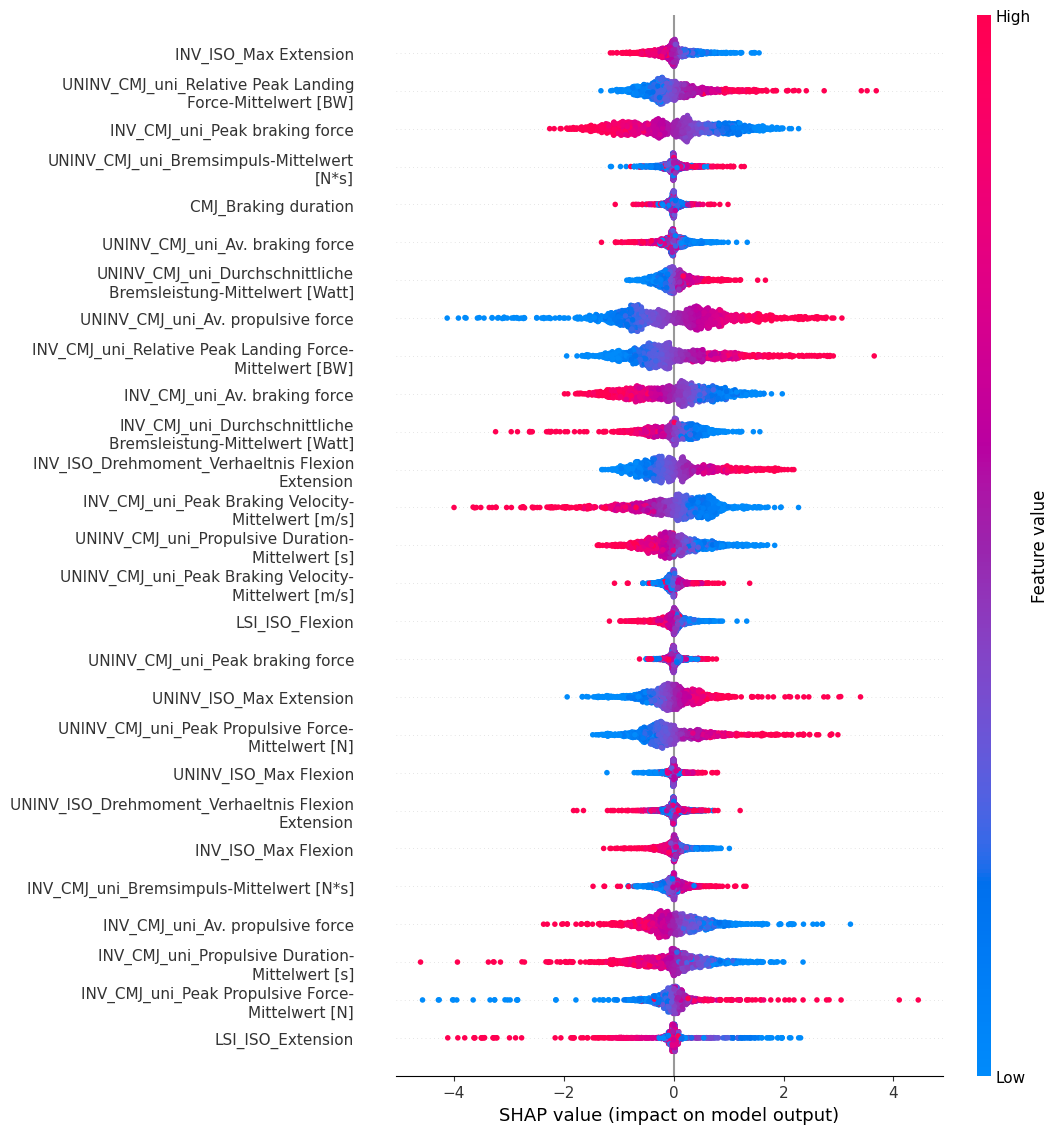

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap
import shap

# gleiche Reihenfolge wie im Barplot → für Beeswarm gespiegelt
feat_order = df_dir["Feature"].tolist()                 # df_dir ist nach |mean(SHAP)| sortiert (absteigend)
idx_map    = {f:i for i,f in enumerate(features)}
order_bar  = np.array([idx_map[f] for f in feat_order]) # Bar-Reihenfolge
order_bee  = order_bar[::-1]                            # Beeswarm: Top oben

# Labels weich umbrechen (z.B. nach 40 Zeichen)
wrapped_names = [textwrap.fill(features[i], width=40) for i in order_bee]

h = 0.35 * len(order_bee) + 2.0   # Höhe skaliert mit Feature-Anzahl
w = 11.0

shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,
    color_bar=True,
    plot_size=(w, h),              # größer machen
    show=False
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)          # größere/weiter weg Labels
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)  # mehr Platz links
plt.tight_layout()
plt.show()


### Median SHAP?!

### Top-N Globaler Plot

→ Top-10-Plot gespeichert unter: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\global_diverging_bar_top10_rest.png


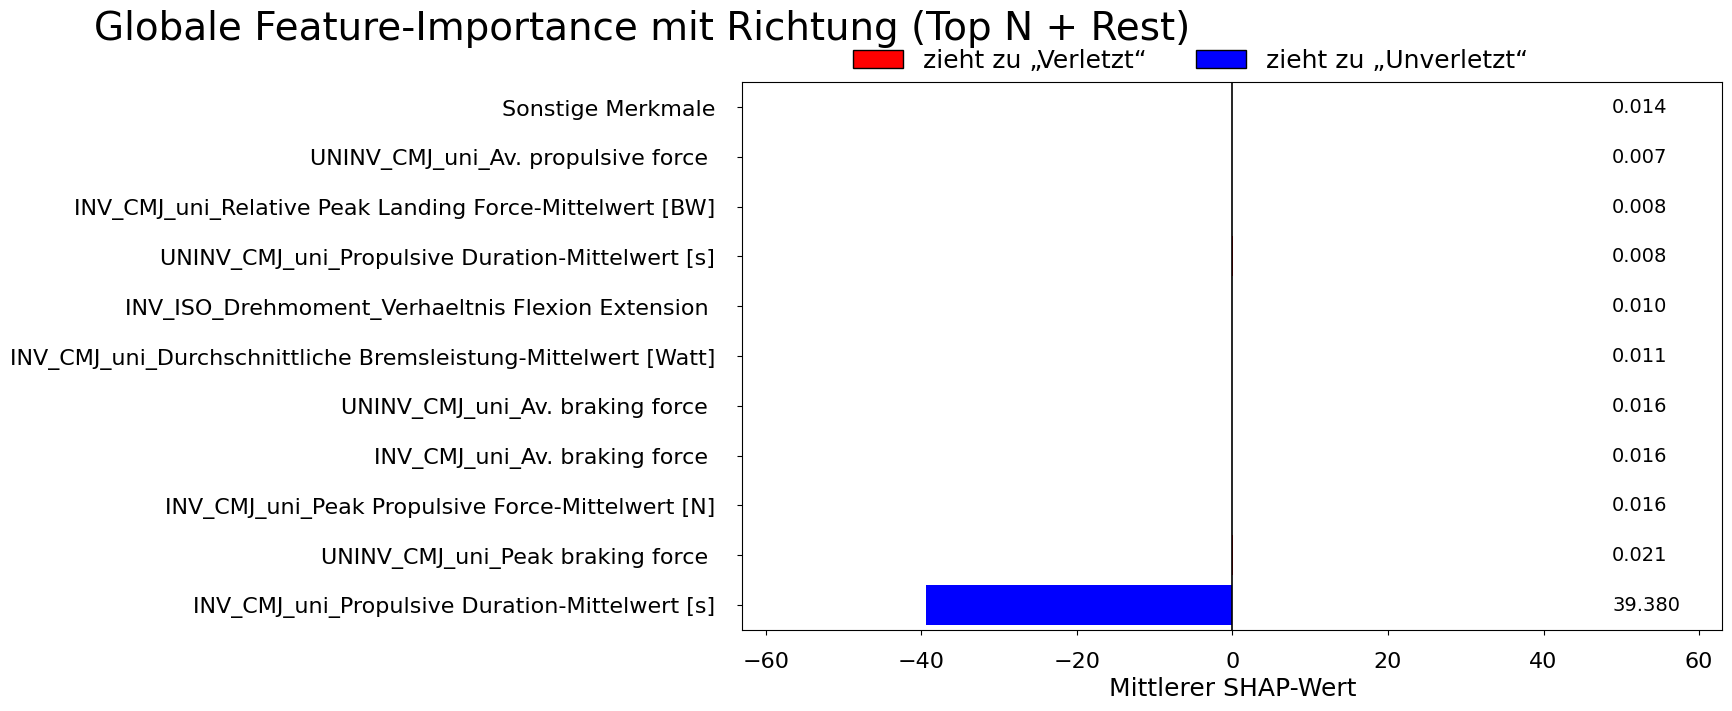

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_global_diverging_bar_topN_with_rest(
    features,
    shap_stack,
    output_dir,
    title="Globale Feature-Importance mit Richtung (Top N + Rest)",
    dpi=200,
    top_n=10  # NEU: Variable Anzahl an Top-Features
):
    mean_shap = np.mean(shap_stack, axis=0)
    abs_mean_shap = np.abs(mean_shap)
    idx_sort = np.argsort(abs_mean_shap)[::-1]

    # Top-N Features und Rest
    top_idxs = idx_sort[:top_n]
    rest_idxs = idx_sort[top_n:]

    top_features = [features[i] for i in top_idxs]
    top_values = mean_shap[top_idxs]
    top_colors = ['red' if val >= 0 else 'blue' for val in top_values]

    # "Rest" berechnen
    rest_value = np.sum(mean_shap[rest_idxs])
    rest_color = 'red' if rest_value >= 0 else 'blue'

    # Plot-Daten zusammenbauen
    bar_labels = top_features + ['Sonstige Merkmale']
    bar_values = np.append(top_values, rest_value)
    bar_colors = top_colors + [rest_color]
    abs_bar_values = np.abs(bar_values)

    # Plotgröße
    fig_h = max(6, len(bar_labels) * 0.6)
    fig_w = 14
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    
    # Legende im Kopfbereich
    legend_elements = [
        Patch(facecolor='red', edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    # Titel und Legende im Kopfbereich kompakt zusammen
    fig.suptitle(title, fontsize=28, y=0.96, ha='right')

    fig.legend(
        handles=legend_elements,
        fontsize=18,
        loc='upper center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.935),  # direkt unter dem Titel
        frameon=False
    )


    # Balken zeichnen
    ax.barh(bar_labels, bar_values, color=bar_colors, height=0.8)
    ax.axvline(0, color='black', linewidth=1.2)

    # Achsen & Beschriftung
    max_abs = abs_bar_values.max()
    margin = max_abs * 0.6
    ax.set_xlim(-max_abs - margin, max_abs + margin)
    ax.set_xlabel("Mittlerer SHAP-Wert", fontsize=18)
    ax.tick_params(axis='y', labelsize=16, pad=16)
    ax.tick_params(axis='x', labelsize=16, pad=12)

    # SHAP-Werte als Text rechts
    x_text = max_abs + margin * 0.4
    for i, val in enumerate(abs_bar_values):
        ax.text(
            x_text,
            i,
            f"{val:.3f}",
            va='center',
            ha='left',
            fontsize=14
        )

    # Layout optimieren
    ax.set_ylim(-0.5, len(bar_labels)-0.5)
    ax.margins(y=0)
    plt.subplots_adjust(top=0.85, bottom=0.02, left=0.18, right=0.88)

    # Speichern & Anzeigen
    out_path = os.path.join(output_dir, f"global_diverging_bar_top{top_n}_rest.png")
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
    print(f"→ Top-{top_n}-Plot gespeichert unter: {out_path}")
    plt.show()

plot_global_diverging_bar_topN_with_rest(
    features=features,
    shap_stack=shap_stack,
    output_dir=shap_output_dir,
    top_n=10
)


### Lokaler Plot

C:\Users\boehmer\AppData\Local\Temp\ipykernel_24700\3010490875.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2)                                  # 2pt Abstand zu Figure-Rand


→ Lokaler Waterfall-Plot mit Kopfzeile: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\local_waterfall_4.png


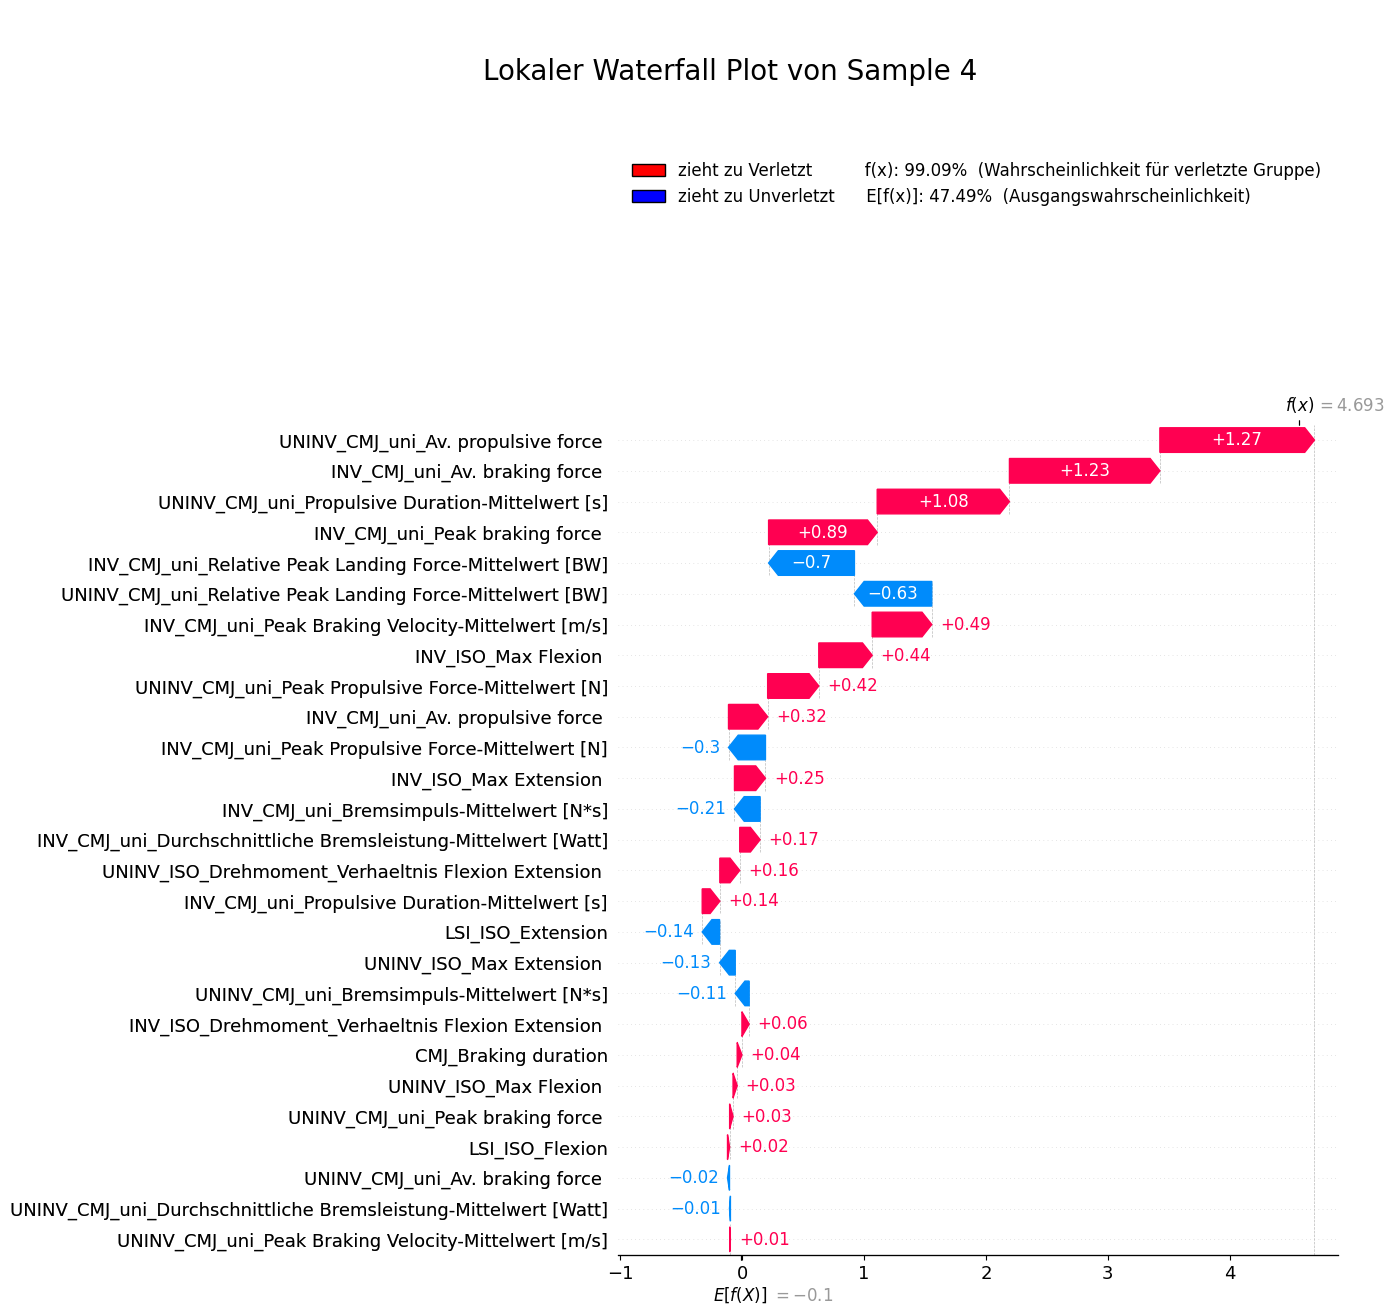

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.special import expit 

shap_output_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"

def plot_local_waterfall(
    features,
    shap_stack,
    X_stack,
    exp_val,
    output_dir,
    sample_idx=None,
    dpi=200
):
    """
    Zeichnet einen lokalen SHAP-Waterfall-Plot mit:
      - Kopfzeile (Title + Legende) im oberen Bereich
      - Direkt darunter den Waterfall, tight am Rand
      - Zusammenfassung aller SHAP=0 Features
    """
    # 1) Sample wählen
    if sample_idx is None:
        np.random.seed(42)
        sample_idx = np.random.choice(shap_stack.shape[0], 1)[0]

    # 2) SHAP-Werte & -Namen
    orig_vals = shap_stack[sample_idx, :]
    orig_names = list(features)

    # 3) Null-Werte zusammenfassen
    zero_mask = orig_vals == 0
    vals_nz   = orig_vals[~zero_mask].tolist()
    names_nz  = [orig_names[i] for i in range(len(orig_names)) if not zero_mask[i]]
    if zero_mask.sum() > 0:
        names_nz.append("Restliche Null-Features")
        vals_nz.append(0.0)

    # 4) Explanation aufbauen
    exp = shap.Explanation(
        values        = np.array(vals_nz),
        base_values   = exp_val,
        feature_names = names_nz,
    )


    fx_logit = exp_val + sum(vals_nz)      # f(x) im Logit
    p_fx     = expit(fx_logit)             # Wahrscheinlichkeit
    p_base   = expit(exp_val)              # Baseline-Wahrscheinlichkeit


    # 5) Figure + GridSpec: 20% Kopf, 80% Plot
    fig = plt.figure(figsize=(10, max(8, len(names_nz)*0.15) + 2))
    gs  = gridspec.GridSpec(
        nrows=2, ncols=1,
        height_ratios=[0.2, 0.8],
        hspace=0.4
    )

    # 6) Kopf-Bereich (unsichtbare Achse)
    ax_header = fig.add_subplot(gs[0])
    ax_header.axis("off")
    ax_header.text(
        0.5, 0.7,
        f"Lokaler Waterfall Plot von Sample {sample_idx}",
        ha="right", va="center",
        fontsize=20
    )

    # Patch-Legende in den Kopfbereich
    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label=f'zieht zu Verletzt          f(x): {p_fx:.2%}  (Wahrscheinlichkeit für verletzte Gruppe)'),
        Patch(facecolor='blue', edgecolor='k', label=f'zieht zu Unverletzt      E[f(x)]: {p_base:.2%}  (Ausgangswahrscheinlichkeit)')
    ]
    ax_header.legend(
        handles=legend_elements,
        fontsize=12,
        loc='upper left',
        bbox_to_anchor=(0.01, 0.3),
        borderaxespad=0.,
        frameon=False
    )



    # 7) Plot-Bereich
    ax_plot = fig.add_subplot(gs[1])
    plt.sca(ax_plot)
    shap.plots.waterfall(
        exp,
        show=False,
        max_display=len(names_nz)
    )


    # 9) Tight am unteren Rand, Sortierung beibehalten
    # ax_plot.set_ylim(-0.5, len(names_nz)-0.5)
    # ax_plot.margins(y=0)
    # plt.tight_layout(pad=0)
    ax_plot.set_ylim(-0.5, len(names_nz)-0.5)
    ax_plot.margins(x=0.025, y=0.22)                          # 5% links/rechts, 2% oben/unten
    plt.tight_layout(pad=2)                                  # 2pt Abstand zu Figure-Rand
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05)  # 5% Abstand links/rechts/unten

    # 9) Speichern und ausgeben
    out = os.path.join(output_dir, f"local_waterfall_{sample_idx}.png")
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f"→ Lokaler Waterfall-Plot mit Kopfzeile: {out}")
    plt.show()


# Aufruf
plot_local_waterfall(
    features=features,
    shap_stack=shap_stack,
    X_stack=X_stack,
    exp_val=exp_val,
    output_dir=shap_output_dir,
    sample_idx=4   # None = zufälliges Sample
)

## Beeswarm und Dependence Plots (Versuch)

In [18]:
# === SHAP: Beeswarm & Dependence nur für Features mit hohem |signed_mean_shap| ===
import os
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

out_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"
os.makedirs(out_dir, exist_ok=True)

# 1) Auswahl/Sortierung nach |signed_mean_shap|
order = np.argsort(np.abs(signed_mean_shaps))[::-1]
top_k = 5  # nach Bedarf anpassen
sel_idx = order[:top_k]
sel_features = [features[i] for i in sel_idx]
print("Top-Features (|signed_mean_shap|):", sel_features)

# 2) Beeswarm NUR mit den ausgewählten Features
X_sel    = X_stack[:, sel_idx]
shap_sel = shap_stack[:, sel_idx]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_sel, X_sel, feature_names=sel_features, show=False)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "beeswarm_top_by_signed_mean.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# 3) Dependence-Plots für die ausgewählten Features
for i, feat_idx in enumerate(sel_idx):
    fname = features[feat_idx]
    plt.figure(figsize=(7.5, 6))
    # Achtung: dependence_plot erwartet globales Array + Index
    shap.dependence_plot(feat_idx, shap_stack, X_stack, feature_names=features, show=False)
    plt.title(f"SHAP Dependence – {fname}")
    plt.tight_layout()
    safe_name = fname.replace('/', '_').replace(':','-')
    plt.savefig(os.path.join(out_dir, f"dep_signedmean_{i:02d}_{safe_name}.png"),
                dpi=300, bbox_inches="tight")
    plt.close()


Top-Features (|signed_mean_shap|): ['INV_CMJ_uni_Propulsive Duration-Mittelwert [s]', 'UNINV_CMJ_uni_Peak braking force ', 'INV_CMJ_uni_Peak Propulsive Force-Mittelwert [N]', 'INV_CMJ_uni_Av. braking force ', 'UNINV_CMJ_uni_Av. braking force ']


### Dependence Plot (auto = am stärksten korreliert) für ein Feature 

Dependence-Plot (auto) für: INV_CMJ_uni_Av. propulsive force 


<Figure size 800x600 with 0 Axes>

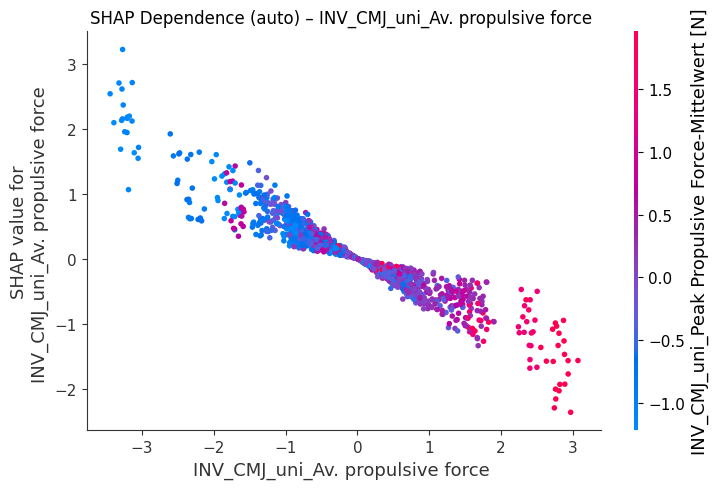

Gespeichert unter: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\dep_auto_INV_CMJ_uni_Av._propulsive_force_.png


In [16]:
import os
import matplotlib.pyplot as plt
import shap

def plot_dependence_auto(feature_name, shap_stack, X_stack, features, out_dir):
    """Dependence Plot mit auto-Interaktion für ein Feature."""
    name_to_idx = {n: i for i, n in enumerate(features)}
    if feature_name not in name_to_idx:
        raise ValueError(f"Feature {feature_name} nicht gefunden.")
    f_idx = name_to_idx[feature_name]

    os.makedirs(out_dir, exist_ok=True)
    print(f"Dependence-Plot (auto) für: {feature_name}")

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        ind=f_idx,
        shap_values=shap_stack,
        features=X_stack,
        feature_names=features,
        interaction_index='auto',
        show=False
    )
    plt.title(f"SHAP Dependence (auto) – {feature_name}")
    plt.tight_layout()
    out_path = os.path.join(out_dir, f"dep_auto_{feature_name.replace(' ','_')}.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Gespeichert unter:", out_path)


if __name__ == "__main__":
    out_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"
    feature_name = "INV_CMJ_uni_Av. propulsive force "

    plot_dependence_auto(feature_name, shap_stack, X_stack, features, out_dir)


### Dependence Plot (explizit) für zwei gewählte Features

In [1]:
import os
import matplotlib.pyplot as plt
import shap

def plot_dependence_pair(feature_x, feature_color, shap_stack, X_stack, features, out_dir):
    """Dependence Plot für Feature_x, eingefärbt nach Feature_color."""
    name_to_idx = {n: i for i, n in enumerate(features)}

    if feature_x not in name_to_idx or feature_color not in name_to_idx:
        raise ValueError("Eines der Features nicht gefunden.")

    f_idx = name_to_idx[feature_x]
    c_idx = name_to_idx[feature_color]

    os.makedirs(out_dir, exist_ok=True)
    print(f"Dependence-Plot für: {feature_x} × {feature_color}")

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        ind=f_idx,
        shap_values=shap_stack,
        features=X_stack,
        feature_names=features,
        interaction_index=c_idx,  # explizit: Farbe nach zweitem Feature
        show=False
    )
    plt.title(f"SHAP Dependence ({feature_x} × {feature_color})")
    plt.tight_layout()
    safe_x = feature_x.replace(" ", "_")
    safe_c = feature_color.replace(" ", "_")
    out_path = os.path.join(out_dir, f"dep_pair_{safe_x}__by__{safe_c}.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Gespeichert unter:", out_path)


if __name__ == "__main__":
    out_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"
    feature_x     = "UNINV_CMJ_uni_Peak braking force"
    feature_color = "UNINV_CMJ_uni_Av. propulsive force"

    plot_dependence_pair(feature_x, feature_color, shap_stack, X_stack, features, out_dir)


NameError: name 'shap_stack' is not defined

### Beeswarm Plot

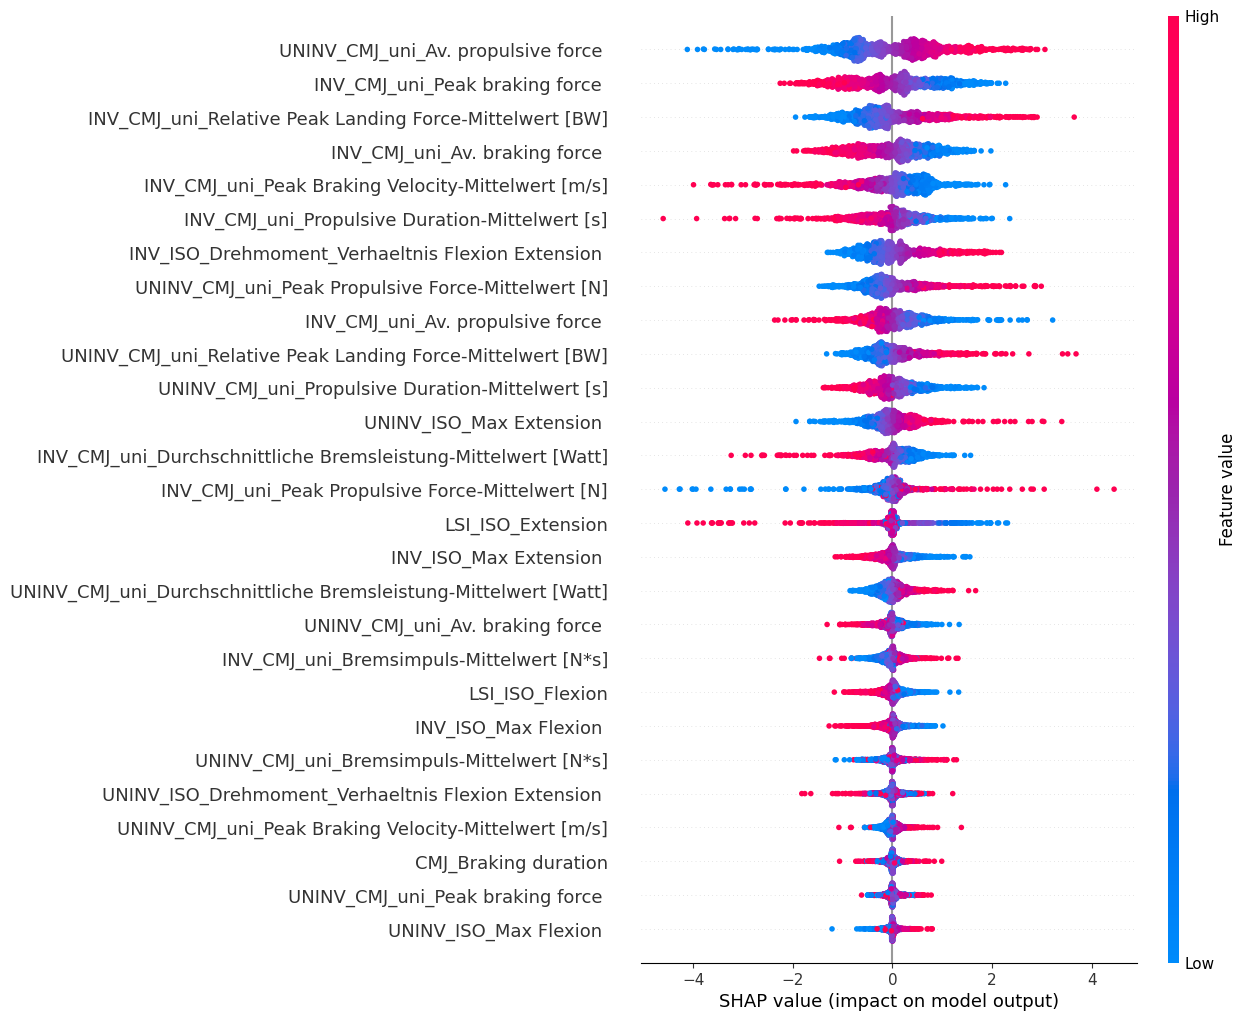

Beeswarm gespeichert: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\beeswarm_signed_order_expl.png


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap

def plot_beeswarm_signed_order_expl(
    shap_stack,
    X_stack,
    features,
    signed_mean_shaps,
    exp_val,
    out_path=None,
    title="SHAP Beeswarm – sortiert nach signed mean (log-odds)"
):
    """
    Beeswarm-Plot über alle Features, sortiert nach signed_mean_shaps (absteigend).
    Nutzt die neue shap.Explanation-API.
    """
    # Sortierung: große positive signed means nach oben
    order_signed = np.argsort(signed_mean_shaps)[::-1]

    # Explanation-Objekt bauen
    base_vals = np.full(shap_stack.shape[0], float(exp_val), dtype=float)
    expl = shap.Explanation(
        values=shap_stack,            # SHAP-Werte (N x F)
        base_values=base_vals,        # pro Sample; hier konstant
        data=X_stack,                 # (N x F) -> färbt die Punkte
        feature_names=features
    )

    # Plotgröße an #Features anpassen
    h = 0.28 * len(features) + 1.5
    plt.figure(figsize=(9, h))

    # Neuer Beeswarm (keine interne Sortierung; wir geben Spaltenreihenfolge vor)
    shap.plots.beeswarm(expl[:, order_signed], max_display=len(features))

    plt.title(title)
    plt.tight_layout()

    if out_path:
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        fig = plt.gcf()
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
        print(f"Beeswarm gespeichert: {out_path}")
    else:
        plt.show()

out_png = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\beeswarm_signed_order_expl.png"

plot_beeswarm_signed_order_expl(
    shap_stack=shap_stack,
    X_stack=X_stack,
    features=features,
    signed_mean_shaps=signed_mean_shaps,
    exp_val=exp_val,        # kommt aus deiner collect_shap_data_lr
    out_path=out_png
)
